In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from belief_dynamics_learning.world2d import World2D
from belief_dynamics_learning.dpf import *
from belief_dynamics_learning.dpf_utils import *

%load_ext autoreload
%autoreload 2

Example demonstration of 2D world, belief of the object pose, and robot trajectory in the 2D world.

In [2]:
num_particles = 100
dt = 0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05


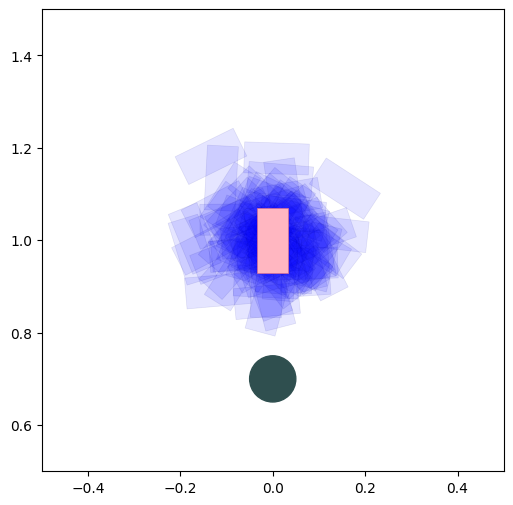

In [3]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

Keeping indices: [74, 94]


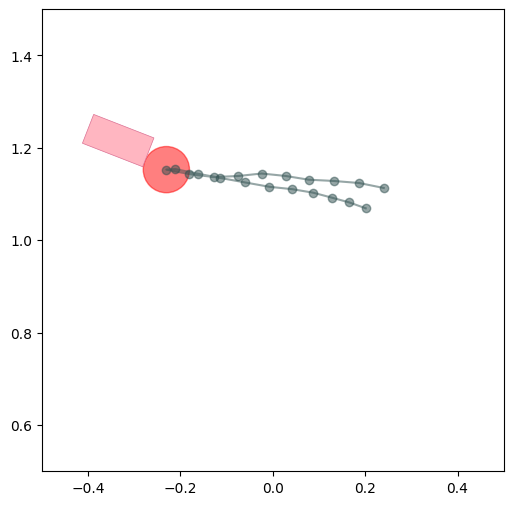

In [4]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

# only keep bits of sequence around positive contact measurements
contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)

Differentiable particle filter

In [5]:
# initialise hyperparameters for the differentiable particle filter (DPF)
propose_ratio = 0.7
proposer_keep_ratio = 0.15 # what it was set to initially and from the paper code
min_obs_likelihood = 0.004

# initialise hyperparameters for the DPF training
split_ratio = 0.8
seq_len = 2
batch_size = 20
num_epochs_pp = 100
num_epochs_ole = 150
patience = 10
learning_rate = 0.0003
dropout_keep_ratio = 0.3
num_particles = 100
particle_std = 0.2
contact_only = True
xy_only = False
phi_dataset = True

# create instance of DPF class
dpf = DPF(propose_ratio, proposer_keep_ratio, min_obs_likelihood, num_particles, world, xy_only, phi_dataset)

Using device: cpu


In [6]:
# find file path to the training data
root = os.getcwd()
save_path = os.path.join(root, '../data/phi_data_min_1_contacts_seq_len_2_test_500_trajectories.pkl')

# ensure the training data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print("File not found:", save_path)

Organise data into a dictionary

Object pose data: (500, 1, 3)
Robot pose data: (500, 2, 2)
q_o_r data: (500, 2, 2)
Phi observation data: (500, 2, 1)
Closest point data: (500, 2, 2)
Object pose (example trajectory): [[-0.38597978  1.27119693 -1.11632874]]
Robot pose (example trajectory): [-0.27699113  1.22352378]
q_o_r data (example trajectory): [-0.10898864  0.04767315]
Phi observation (example trajectory): [-0.57625067]
Closest point (example trajectory): [-0.03138804  0.04830245]


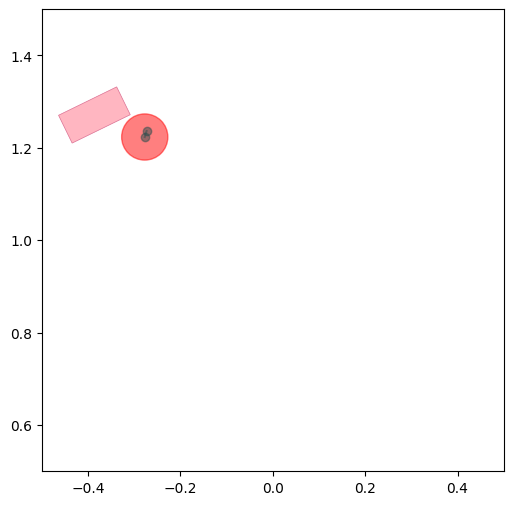

In [7]:
# data generation parameters
num_sequences = 500
num_steps_per_sequence = seq_len

data = organise_data(raw_data, num_sequences, num_steps_per_sequence, contact_only, xy_only)
    
# verify shapes of matrices containing 
print('Object pose data:', data['q_o'].shape)
print('Robot pose data:', data['q_r'].shape)
print('q_o_r data:', data['q_o_r'].shape)
print('Phi observation data:', data['phi'].shape)
print('Closest point data:', data['cp'].shape)

# plot example trajectory from the dataset
traj = np.random.randint(0, num_sequences)
print('Object pose (example trajectory):', data['q_o'][traj, :, :])
print('Robot pose (example trajectory):', data['q_r'][traj, 0, :])
print('q_o_r data (example trajectory):', data['q_o_r'][traj, 0, :])
print('Phi observation (example trajectory):', data['phi'][traj, 0, :])
print('Closest point (example trajectory):', data['cp'][traj, 0, :])
world.qo_gt = data['q_o'][traj, 0, :]
world.plot_rollout(data['q_r'][traj, :, :], 1)
# world.plot_rollout(data['q_r'][traj, :, :], data['o'][traj, :, :])

In [8]:
# noisify data
data = noisify_data(data)

In [9]:
# compute some statistics aboout the data
means, stds, q_o_r_maxs, q_o_r_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data, phi_dataset)
print('q_o_r_mins:', q_o_r_mins)

q_o_r_mins: [-0.14320088 -0.13836676]


In [10]:
# # create dataset and dataloader for training and validation
# train_dataset = TrajectoriesDataset(train_data, seq_len)
# val_dataset = TrajectoriesDataset(val_data, seq_len)

# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

# # test the dataloader
# for batch in train_dataloader:
#     print(batch['q_o'].shape)  # Expected shape: [20, 1, 3]
#     print(batch['q_r'].shape)  # Expected shape: [20, 100, 2]
#     print(batch['q_o_r'].shape) # Expected shape: [20, 100, 1]
#     print(batch['phi'].shape)    # Expected shape: [20, 100, 2]
#     break

Before training:

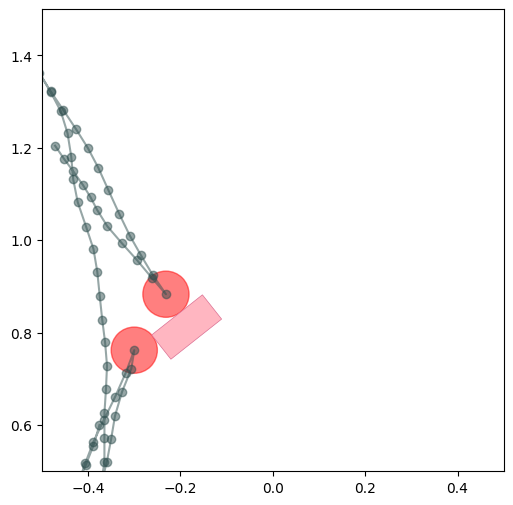

Desired robot position during contact event: tensor([[-0.2264,  0.8773]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[-0.2311,  0.8833]], dtype=torch.float64)
Phi during contact event: tensor([[2.4723]], dtype=torch.float64)


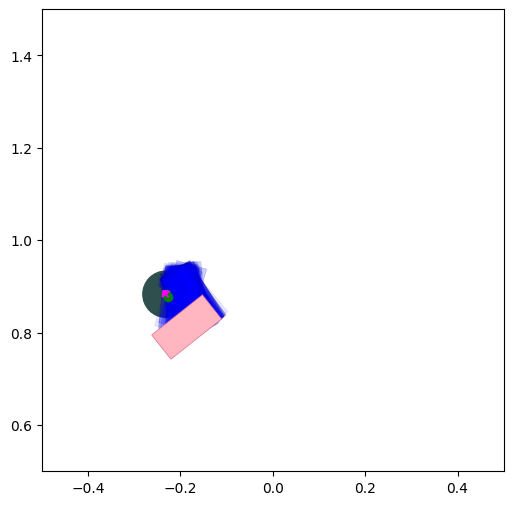

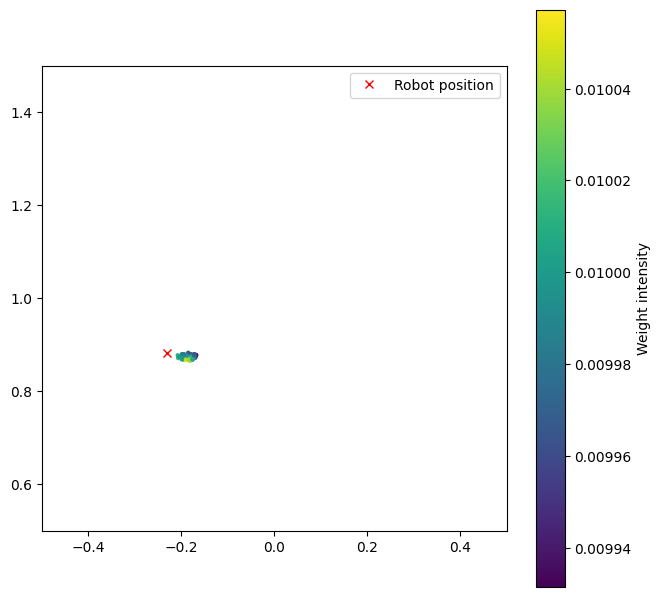

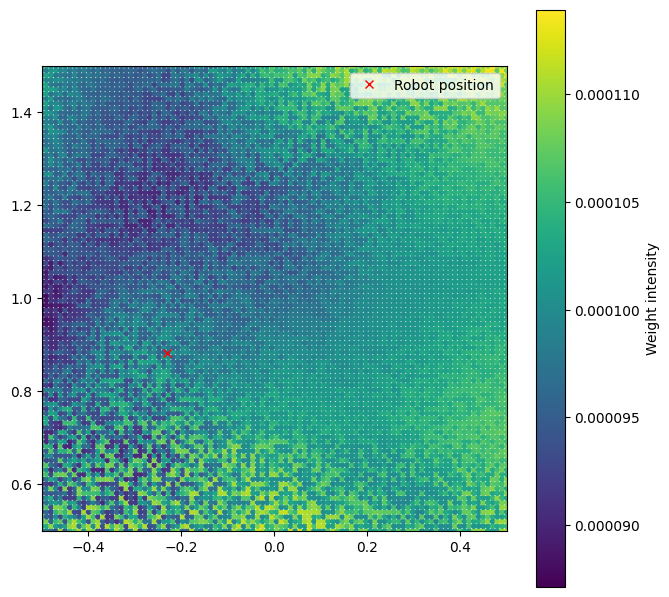

In [11]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
Epoch 27/100
Epoch 28/100
Epoch 29/100
Epoch 30/100
Epoch 31/100
Epoch 32/100
Epoch 33/100
Epoch 34/100
Epoch 35/100
Epoch 36/100
Epoch 37/100
Epoch 38/100
Epoch 39/100
Epoch 40/100
Epoch 41/100
Epoch 42/100
Epoch 43/100
Epoch 44/100
Epoch 45/100
Epoch 46/100
Epoch 47/100
Epoch 48/100
Epoch 49/100
Epoch 50/100
Epoch 51/100
Epoch 52/100
Epoch 53/100
Epoch 54/100
Epoch 55/100
Epoch 56/100
Epoch 57/100
Epoch 58/100
Epoch 59/100
Epoch 60/100
Epoch 61/100
Epoch 62/100
Epoch 63/100
Epoch 64/100
Epoch 65/100
Epoch 66/100
Epoch 67/100
Epoch 68/100
Epoch 69/100
Epoch 70/100
Epoch 71/100
Epoch 72/100
Epoch 73/100
Epoch 74/100
Epoch 75/100
Epoch 76/100
Epoch 77/100
Epoch 78

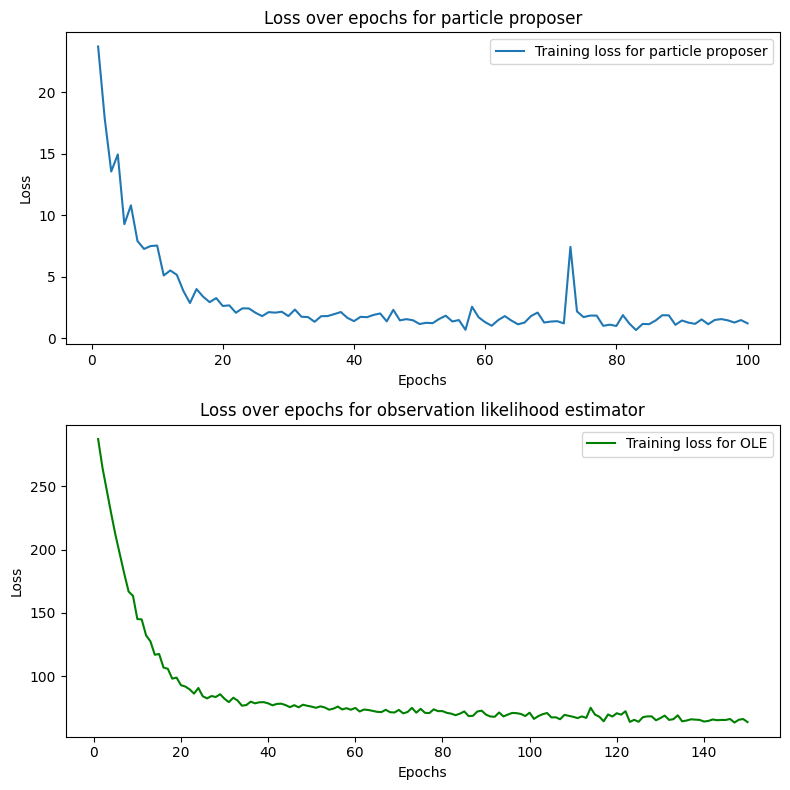

In [12]:
if contact_only == True:
    seq_len = 1

# train the dpf and extract the last batch from training
dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs_pp, num_epochs_ole, learning_rate, num_particles, xy_only, phi_dataset)

# q_o, particle_list, particle_prob_list = dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs_pp, patience, learning_rate, num_particles, xy_only, phi_dataset) # form GMM plots

After training:

In [13]:
# # plot GMM
# dpf.plot_GMM(q_o, particle_list, particle_prob_list, xy_only)

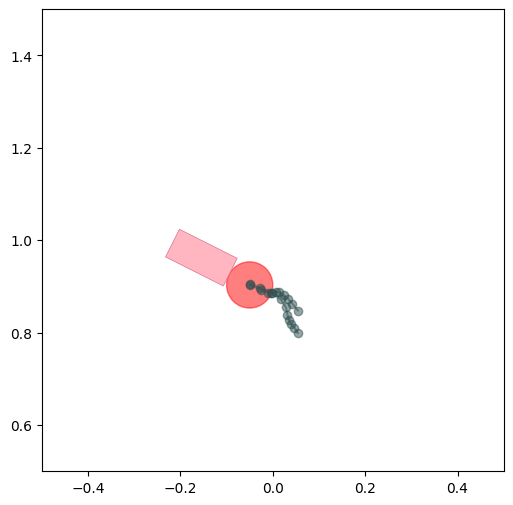

Desired robot position during contact event: tensor([[-0.0741,  0.9155]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[-0.0499,  0.9033]], dtype=torch.float64)
Phi during contact event: tensor([[-1.1051]], dtype=torch.float64)


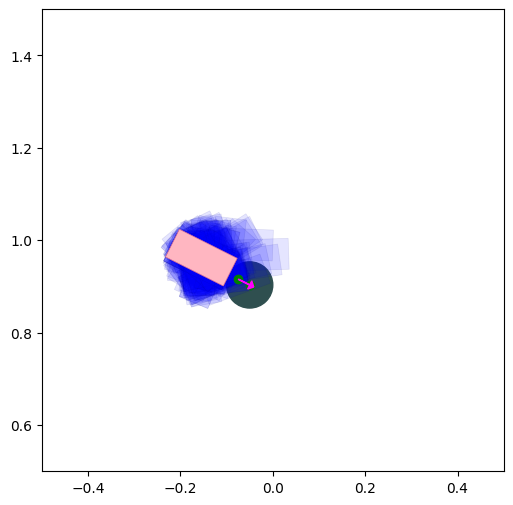

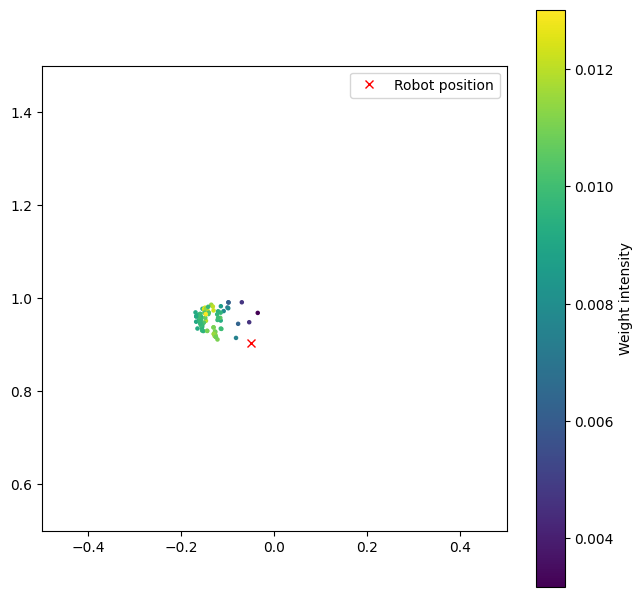

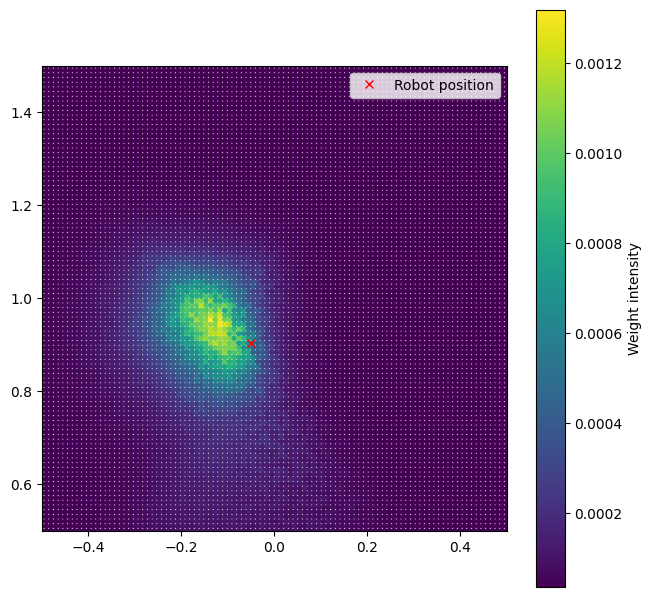

In [17]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)